In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [4]:
import zipfile

with zipfile.ZipFile('Fake.csv.zip', 'r') as zip_ref:
    zip_ref.extractall()

with zipfile.ZipFile('True.csv.zip', 'r') as zip_ref:
    zip_ref.extractall()

print("Files extracted successfully!")

Files extracted successfully!


In [5]:
import os
print(os.listdir())

['.config', 'drive', 'True.csv.zip', 'Fake.csv', 'True.csv', 'Fake.csv.zip', 'sample_data']


In [6]:
fake_df = pd.read_csv("Fake.csv")
true_df = pd.read_csv("True.csv")

print("Fake News Shape:", fake_df.shape)
print("True News Shape:", true_df.shape)

Fake News Shape: (23481, 4)
True News Shape: (21417, 4)


In [7]:
# Add labels
fake_df['label'] = 0
true_df['label'] = 1

# Merge datasets
df = pd.concat([fake_df, true_df], ignore_index=True)

print("Total rows:", len(df))
print(df[['text', 'label']].head())

Total rows: 44898
                                                text  label
0  Donald Trump just couldn t wish all Americans ...      0
1  House Intelligence Committee Chairman Devin Nu...      0
2  On Friday, it was revealed that former Milwauk...      0
3  On Christmas day, Donald Trump announced that ...      0
4  Pope Francis used his annual Christmas Day mes...      0


In [8]:
df = df[['text', 'label']]

print(df.shape)
df.head()

(44898, 2)


,text,label
0,Donald Trump just couldn t wish all Americans ...,0
1,House Intelligence Committee Chairman Devin Nu...,0
2,"On Friday, it was revealed that former Milwauk...",0
3,"On Christmas day, Donald Trump announced that ...",0
4,Pope Francis used his annual Christmas Day mes...,0


In [9]:
print(df.isnull().sum())

text     0
label    0
dtype: int64


In [10]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df.head()

,text,label
0,"21st Century Wire says Ben Stein, reputable pr...",0
1,WASHINGTON (Reuters) - U.S. President Donald T...,1
2,(Reuters) - Puerto Rico Governor Ricardo Rosse...,1
3,"On Monday, Donald Trump once again embarrassed...",0
4,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",1


In [11]:
df = df.sample(10000, random_state=42)

print(df.shape)

(10000, 2)


In [13]:
X = df['text']
y = df['label']

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(8000,)
(2000,)


In [15]:
df = df.sample(10000, random_state=42)

print(df.shape)

(10000, 2)


In [16]:
X = df['text']
y = df['label']

print(X.shape)
print(y.shape)

(10000,)
(10000,)


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 8000
Testing Samples: 2000


In [18]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

print("Tokenization completed!")

Tokenization completed!


In [19]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_length = 200

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length
)

print(X_train_pad.shape)
print(X_test_pad.shape)

(8000, 200)
(2000, 200)


In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

model = Sequential([
    Embedding(input_dim=5000, output_dim=64, input_length=200),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [21]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=3,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/3
200/200 ━━━━━━━━━━━━━━━━━━━━ 21s 94ms/step - accuracy: 0.9261 - loss: 0.2095 - val_accuracy: 0.9669 - val_loss: 0.0858
Epoch 2/3
200/200 ━━━━━━━━━━━━━━━━━━━━ 20s 100ms/step - accuracy: 0.9880 - loss: 0.0398 - val_accuracy: 0.9756 - val_loss: 0.0870
Epoch 3/3
200/200 ━━━━━━━━━━━━━━━━━━━━ 19s 95ms/step - accuracy: 0.9922 - loss: 0.0285 - val_accuracy: 0.9844 - val_loss: 0.0513


In [22]:
loss, accuracy = model.evaluate(X_test_pad, y_test)

print("Test Accuracy:", accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9815 - loss: 0.0634
Test Accuracy: 0.9815000295639038


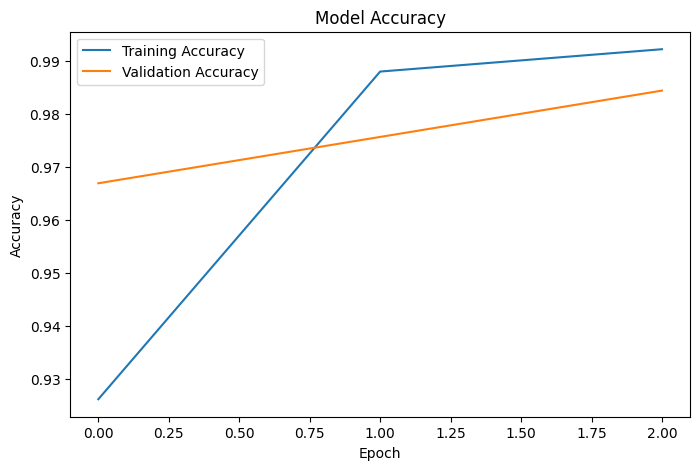

In [23]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [24]:
model.save("fake_news_detector.h5")
print("Model saved successfully!")

Model saved successfully!


In [25]:
sample_text = [
    "Scientists discover a new planet that could support life."
]

seq = tokenizer.texts_to_sequences(sample_text)
pad = pad_sequences(seq, maxlen=200)

prediction = model.predict(pad)

print("Prediction Score:", prediction[0][0])

if prediction[0][0] > 0.5:
    print("Real News")
else:
    print("Fake News")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
Prediction Score: 0.025751118
Fake News
